# End-to-End Machine Learning Exercise


**Prepared by:** **Ali H. El-Kassas**  
*Senior Data Scientist | Machine Learning Instructor*

This notebook is intended to help students practice the complete machine learning workflow, including exploratory data analysis, data preprocessing, feature engineering, model training, hyperparameter tuning, and error analysis.

Complete all `TODO` sections.

### Objectives

Build a machine learning pipeline that predicts the Manufacturer Suggested Retail Price (MSRP) of a car.

- Frame the problem
- Select a Performance Measure
- Quick look on the data
- Train/Validation/Test split
- EDA
- Preprocessing
- Pipelines
- Modeling
- Fine-Tuning
- Error Analysis
- Final Evaluation
- Deploy the model

In [273]:
# TODO Import all the lib that you need here

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

import joblib

In [274]:
# TODO: Load the dataset
df = pd.read_csv('data.csv')

## Initial Inspection
Inspect shape, dtypes, missing values, duplicates and descriptive statistics.

In [275]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [276]:
# TODO
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [277]:
# TODO
df.shape

(11914, 16)

In [278]:
df.dtypes

Make                     str
Model                    str
Year                   int64
Engine Fuel Type         str
Engine HP            float64
Engine Cylinders     float64
Transmission Type        str
Driven_Wheels            str
Number of Doors      float64
Market Category          str
Vehicle Size             str
Vehicle Style            str
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

In [279]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [280]:
df.duplicated().sum()

np.int64(715)

In [281]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [282]:
df = df.drop_duplicates()

In [283]:
df[df.MSRP>=2000000]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11362,Bugatti,Veyron 16.4,2008,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,14,8,820,2065902


In [284]:
df.shape

(11199, 16)

In [285]:
df[df['Engine Cylinders']==0]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
539,FIAT,500e,2015,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,2.0,Hatchback,Compact,2dr Hatchback,108,122,819,31800
540,FIAT,500e,2016,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,2.0,Hatchback,Compact,2dr Hatchback,103,121,819,31800
541,FIAT,500e,2017,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,2.0,Hatchback,Compact,2dr Hatchback,103,121,819,31800
1680,Mercedes-Benz,B-Class Electric Drive,2015,electric,177.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,"Hatchback,Luxury",Compact,4dr Hatchback,82,85,617,41450
1681,Mercedes-Benz,B-Class Electric Drive,2016,electric,177.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,"Hatchback,Luxury",Compact,4dr Hatchback,82,85,617,41450
1682,Mercedes-Benz,B-Class Electric Drive,2017,electric,177.0,0.0,DIRECT_DRIVE,front wheel drive,4.0,"Hatchback,Luxury",Compact,4dr Hatchback,82,85,617,39900
4705,Honda,Fit EV,2013,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,105,132,2202,36625
4706,Honda,Fit EV,2014,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,105,132,2202,36625
4785,Ford,Focus,2015,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,99,110,5657,29170
4789,Ford,Focus,2016,electric,NaN,0.0,DIRECT_DRIVE,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,99,110,5657,29170


In [286]:
df[df['Engine Cylinders']==16]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11362,Bugatti,Veyron 16.4,2008,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,14,8,820,2065902
11363,Bugatti,Veyron 16.4,2008,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,14,8,820,1500000
11364,Bugatti,Veyron 16.4,2009,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,14,8,820,1705769


In [287]:
df = df[df['highway MPG']!=354]

In [288]:
df

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [289]:
df.info()

<class 'pandas.DataFrame'>
Index: 11198 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11198 non-null  str    
 1   Model              11198 non-null  str    
 2   Year               11198 non-null  int64  
 3   Engine Fuel Type   11195 non-null  str    
 4   Engine HP          11129 non-null  float64
 5   Engine Cylinders   11168 non-null  float64
 6   Transmission Type  11198 non-null  str    
 7   Driven_Wheels      11198 non-null  str    
 8   Number of Doors    11192 non-null  float64
 9   Market Category    7822 non-null   str    
 10  Vehicle Size       11198 non-null  str    
 11  Vehicle Style      11198 non-null  str    
 12  highway MPG        11198 non-null  int64  
 13  city mpg           11198 non-null  int64  
 14  Popularity         11198 non-null  int64  
 15  MSRP               11198 non-null  int64  
dtypes: float64(3), int64(5), str(8)
memory

In [290]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11198.000000,11129.000000,11168.000000,11192.000000,11198.000000,11198.000000,11198.000000,1.119800e+04
mean,2010.713967,253.388984,5.666100,3.454074,26.581354,19.731470,1558.345240,4.192506e+04
std,7.228290,110.155886,1.797033,0.872970,8.428038,9.177876,1445.659544,6.153773e+04
min,1990.000000,55.000000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,172.000000,4.000000,2.000000,22.000000,16.000000,549.000000,2.159925e+04
50%,2015.000000,239.000000,6.000000,4.000000,25.000000,18.000000,1385.000000,3.067500e+04
75%,2016.000000,303.000000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.302750e+04
max,2017.000000,1001.000000,16.000000,4.000000,111.000000,137.000000,5657.000000,2.065902e+06


## Train / Validation / Test Split
Split data into Train, Validation and Test sets.

In [291]:
# TODO
X = df.drop(columns="MSRP")
y = df['MSRP']
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.20,random_state=4)
X_train , X_val , y_train , y_val = train_test_split(X_train , y_train , test_size=0.20,random_state=4)

## Exploratory Data Analysis

### Numerical Features



- Histograms
- KDE plots
- Boxplots
- Distribution of MSRP
- Identify skewed features

In [292]:
# TODO
train_df = X_train.copy()
train_df['MSRP'] = y_train

numerical_columns = train_df.select_dtypes(include=np.number).columns.tolist()

numerical_columns

['Year',
 'Engine HP',
 'Engine Cylinders',
 'Number of Doors',
 'highway MPG',
 'city mpg',
 'Popularity',
 'MSRP']

- Histograms

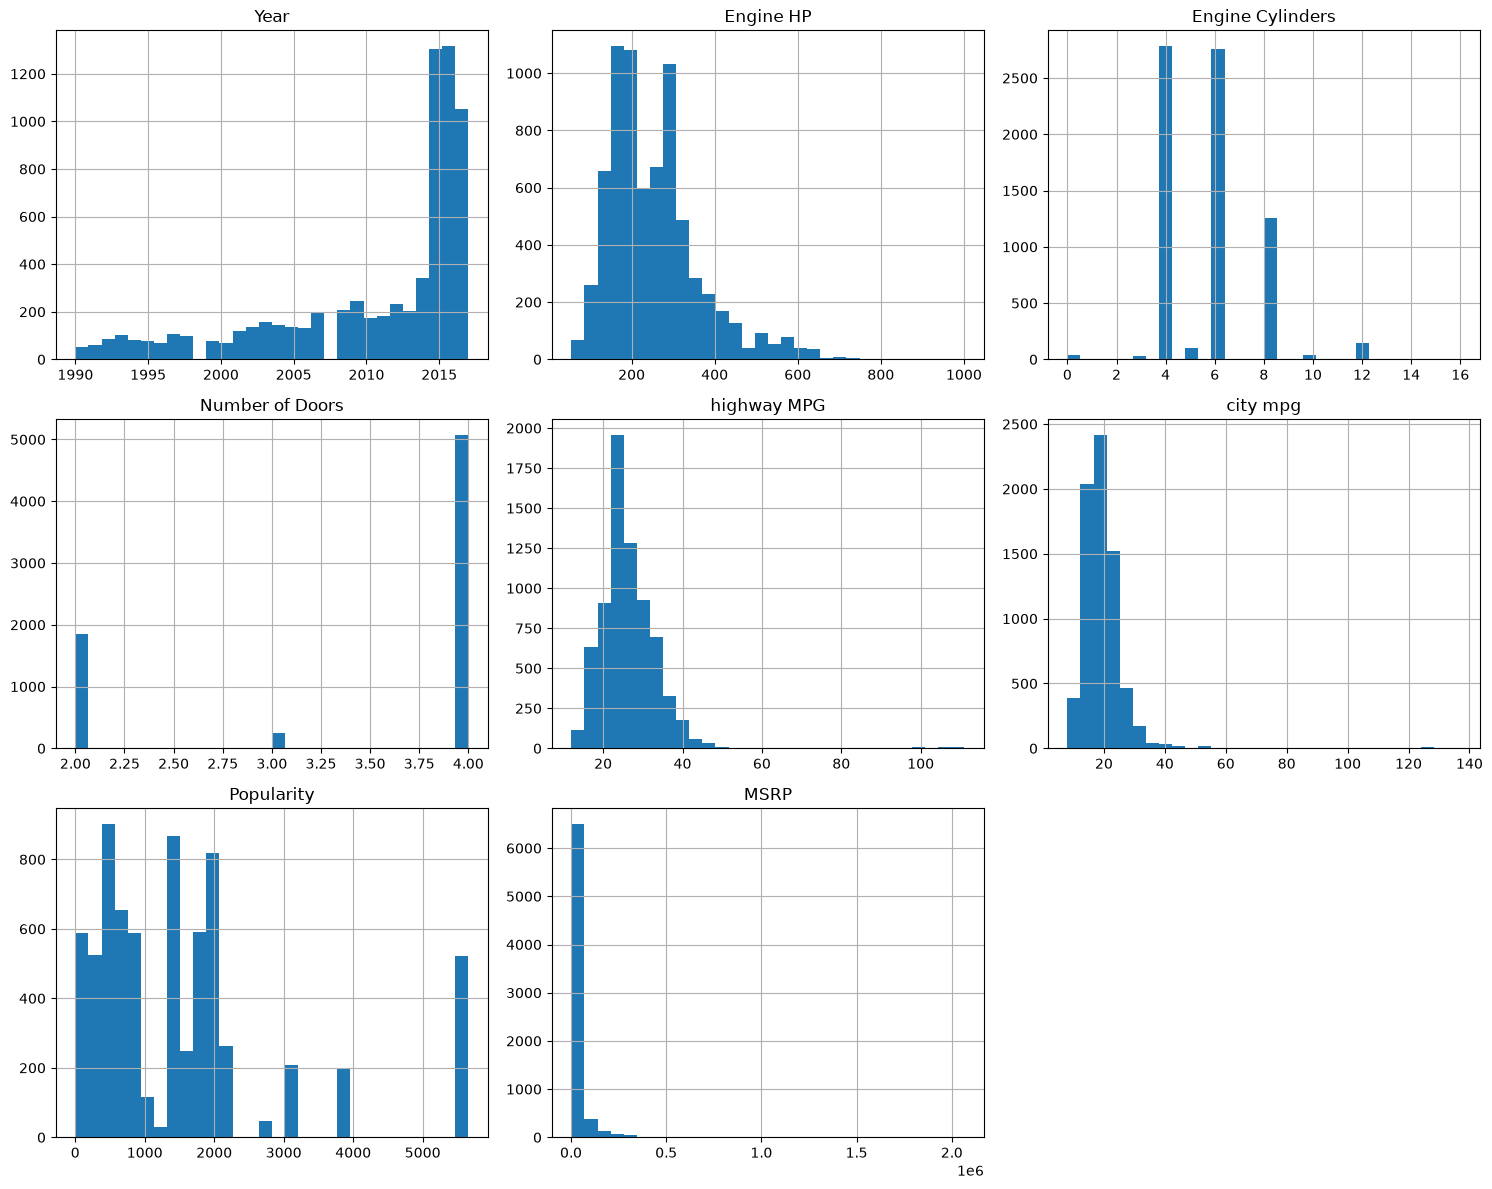

In [293]:
train_df[numerical_columns].hist(figsize=(15, 12), bins=30)

plt.tight_layout()
plt.show()

- KDE Plots

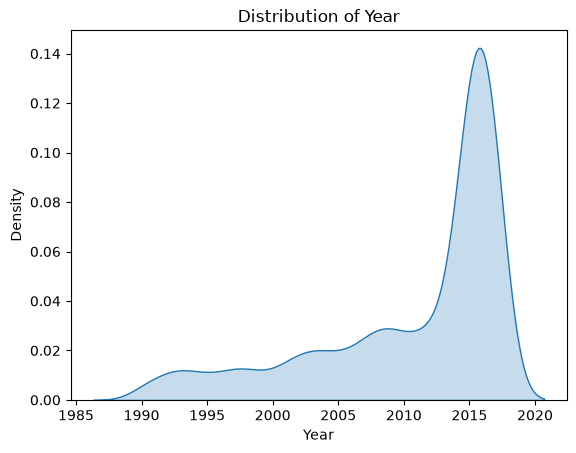

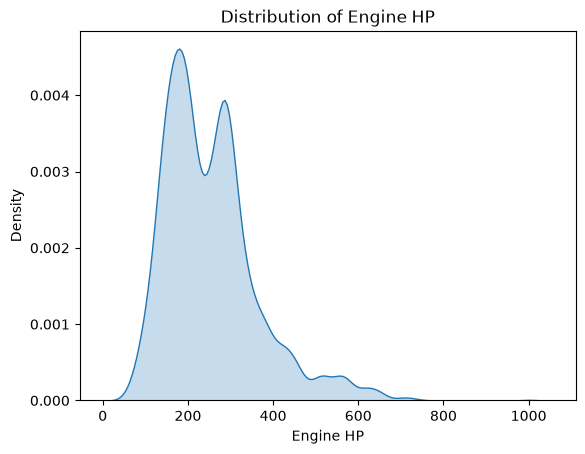

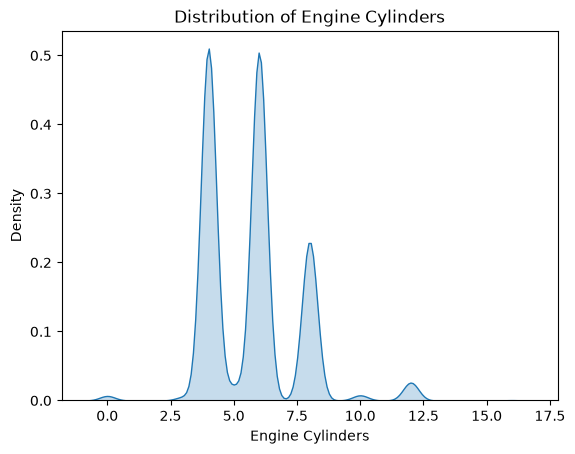

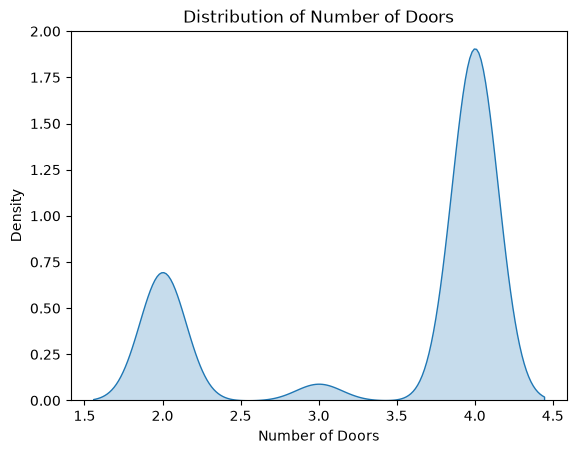

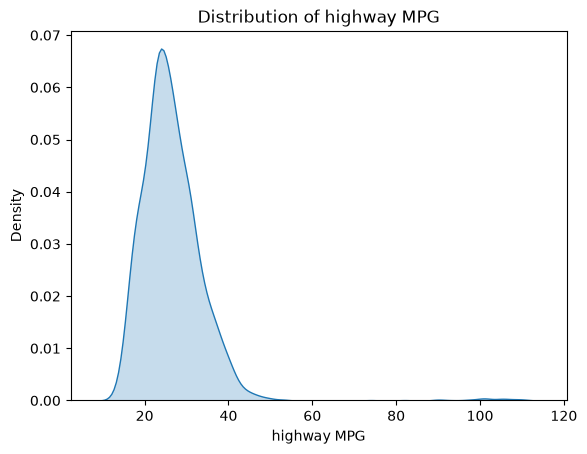

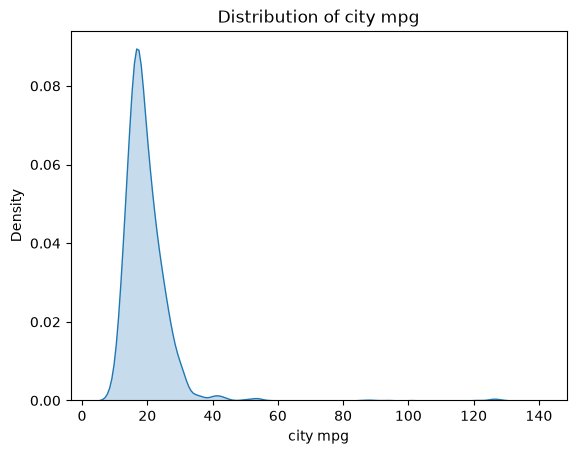

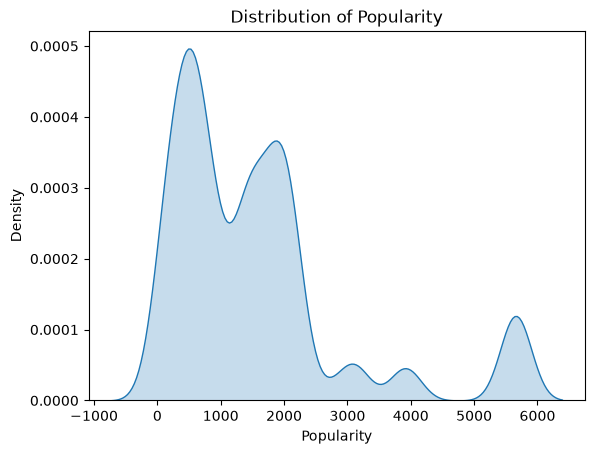

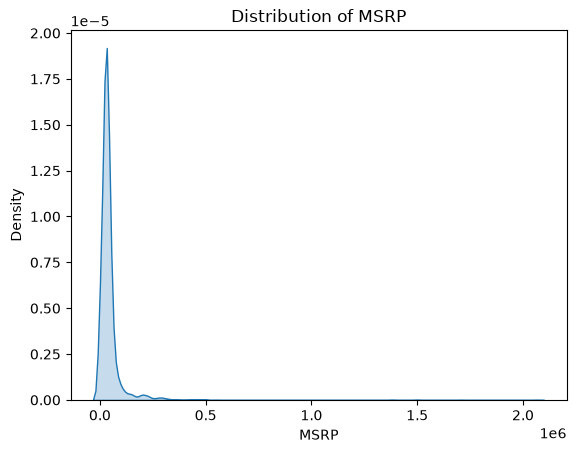

In [294]:
for column in numerical_columns:
    sns.kdeplot(data=train_df, x=column, fill=True)
    plt.title(f'Distribution of {column}')
    plt.show()

- Boxplots

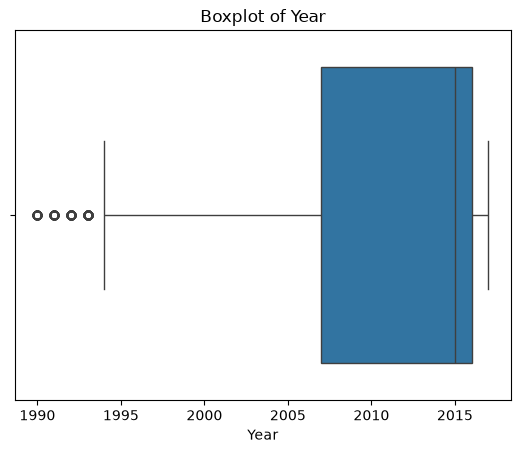

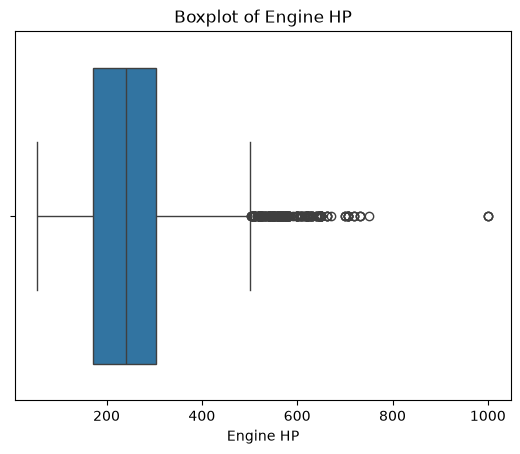

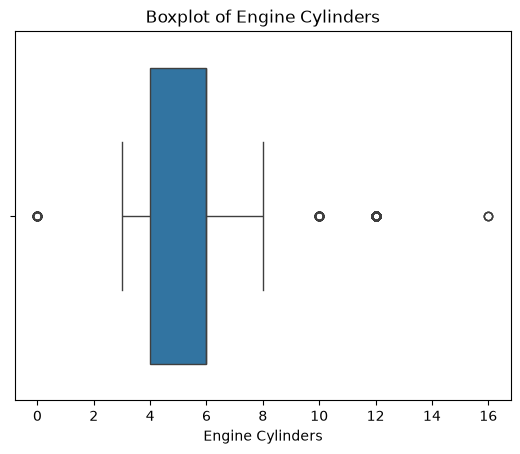

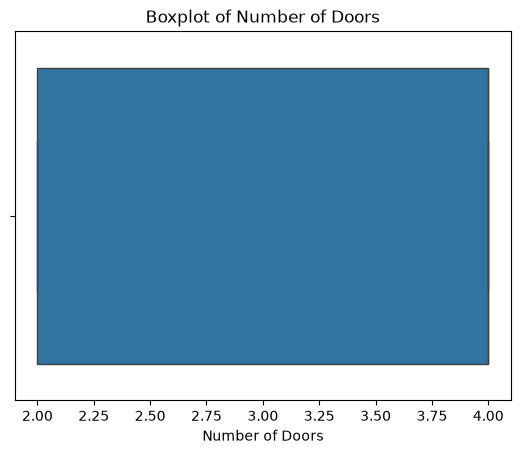

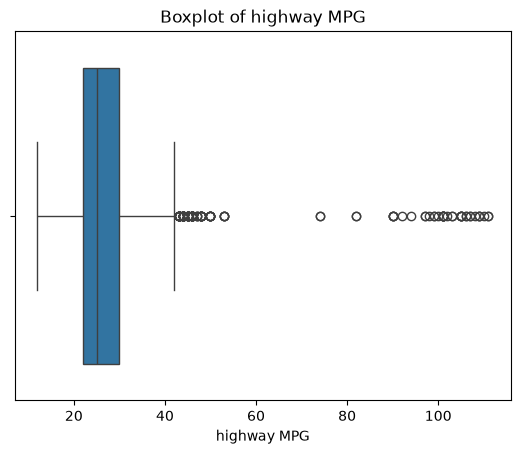

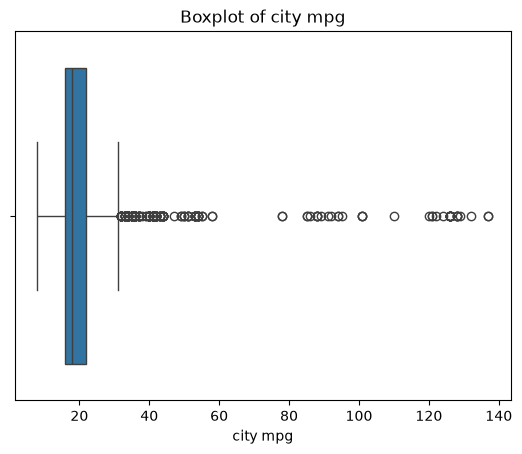

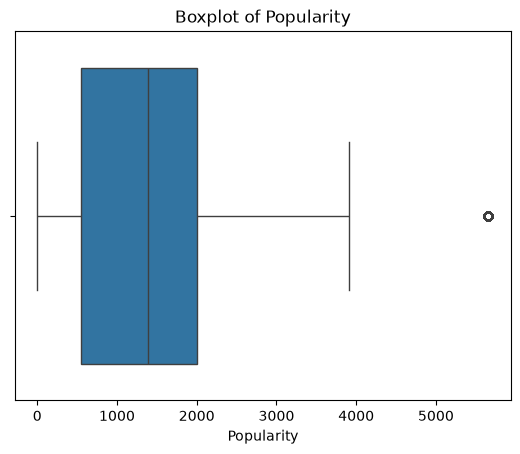

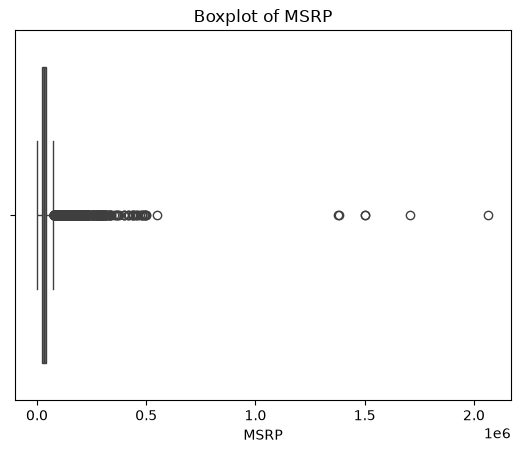

In [295]:
for column in numerical_columns:
    sns.boxplot(data=train_df, x=column)
    plt.title(f'Boxplot of {column}')
    plt.show()

- Distribution of MSRP

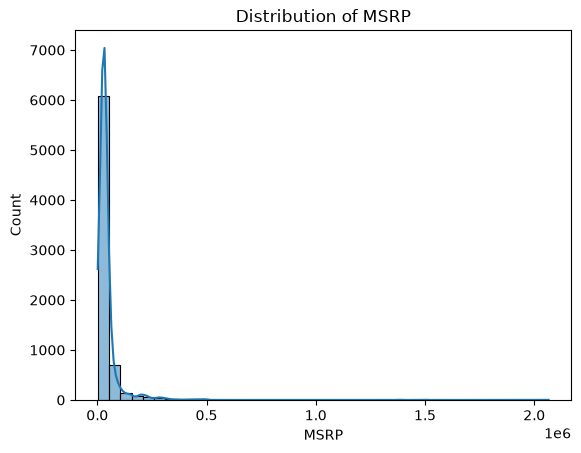

In [296]:
sns.histplot(data=train_df,x='MSRP',bins=40,kde=True)

plt.title('Distribution of MSRP')
plt.show()

- Identify Skewed Features

In [297]:
train_df[numerical_columns].skew().sort_values(ascending=False)

MSRP                13.040793
city mpg             7.097284
highway MPG          4.161382
Popularity           1.643561
Engine HP            1.273938
Engine Cylinders     0.941924
Number of Doors     -1.007151
Year                -1.242302
dtype: float64

## Outlier Detection


- Identify outliers using boxplots
- Decide whether to remove them and explain why?

### answer :

- I decided not to remove the outliers because many expensive cars are real luxury and high-performance vehicles, not data errors. Removing them may make the model unable to predict expensive cars correctly.

### Categorical Features



- Countplots
- Number of unique values

In [298]:
# TODO
categorical_columns = train_df.select_dtypes(include='str').columns.tolist()

categorical_columns

['Make',
 'Model',
 'Engine Fuel Type',
 'Transmission Type',
 'Driven_Wheels',
 'Market Category',
 'Vehicle Size',
 'Vehicle Style']

In [299]:
X_train[categorical_columns].nunique().sort_values(ascending=False)

Model                881
Market Category       70
Make                  48
Vehicle Style         16
Engine Fuel Type      10
Transmission Type      5
Driven_Wheels          4
Vehicle Size           3
dtype: int64

In [300]:
X_train['Vehicle Style'].unique()

<ArrowStringArray>
[              'Sedan', 'Extended Cab Pickup',             '2dr SUV',
             '4dr SUV',   'Passenger Minivan',         'Convertible',
       '2dr Hatchback',  'Regular Cab Pickup',               'Coupe',
       'Passenger Van',               'Wagon',     'Crew Cab Pickup',
       '4dr Hatchback',           'Cargo Van',       'Cargo Minivan',
     'Convertible SUV']
Length: 16, dtype: str

In [301]:
X_train['Engine Fuel Type'].unique()

<ArrowStringArray>
[                                    'electric',
                             'regular unleaded',
                  'premium unleaded (required)',
                     'flex-fuel (unleaded/E85)',
               'premium unleaded (recommended)',
                                       'diesel',
 'flex-fuel (premium unleaded recommended/E85)',
    'flex-fuel (premium unleaded required/E85)',
             'flex-fuel (unleaded/natural gas)',
                                  'natural gas']
Length: 10, dtype: str

In [302]:
X_train['Transmission Type'].unique()

<ArrowStringArray>
['DIRECT_DRIVE', 'AUTOMATIC', 'UNKNOWN', 'MANUAL', 'AUTOMATED_MANUAL']
Length: 5, dtype: str

In [303]:
X_train['Driven_Wheels'].unique()

<ArrowStringArray>
['all wheel drive', 'rear wheel drive', 'front wheel drive',
 'four wheel drive']
Length: 4, dtype: str

In [304]:
X_train['Vehicle Size'].unique()

<ArrowStringArray>
['Large', 'Compact', 'Midsize']
Length: 3, dtype: str

In [305]:
selected_categorical = ['Engine Fuel Type','Transmission Type','Driven_Wheels','Vehicle Size','Vehicle Style']

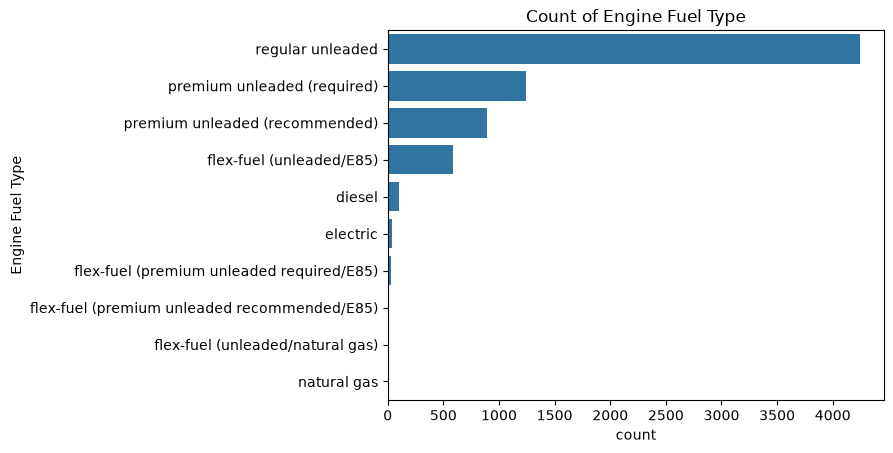

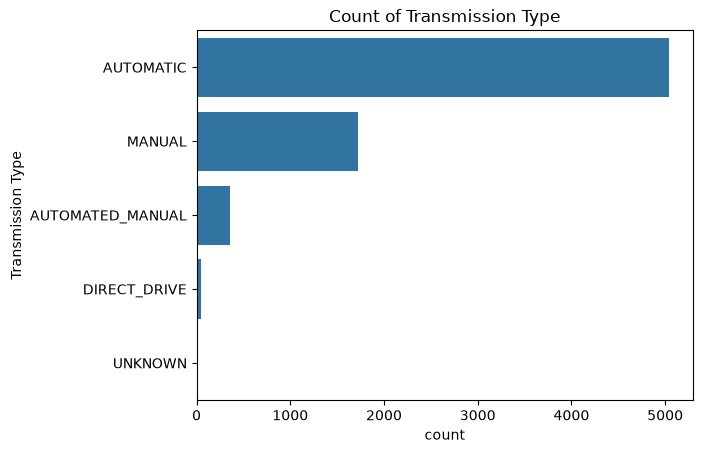

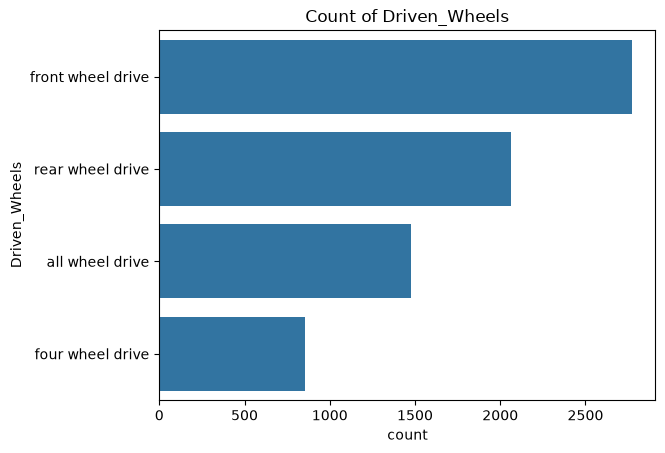

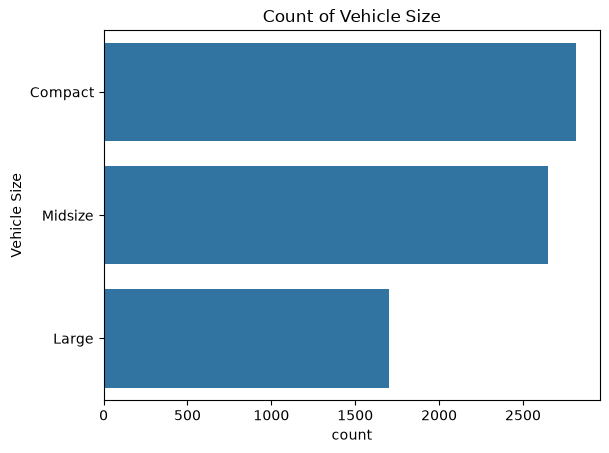

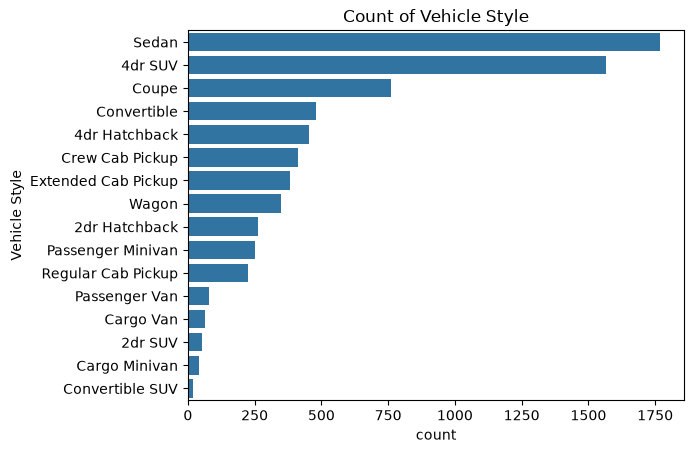

In [306]:
for column in selected_categorical:

    sns.countplot(data = X_train , y = column , order = X_train[column].value_counts().index)

    plt.title(f'Count of {column}')
    plt.show()

### Relationship with Target

Tasks

- Scatterplots
- Correlation heatmap
- Pairplots (selected columns)


In [307]:
# TODO
selected_numeric = ['Engine HP','Engine Cylinders','highway MPG','city mpg','Popularity']

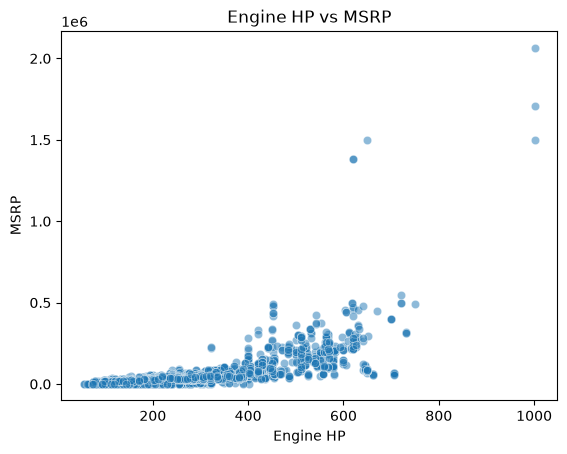

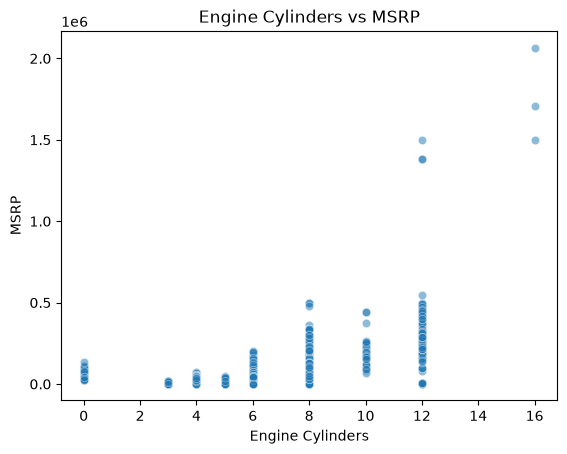

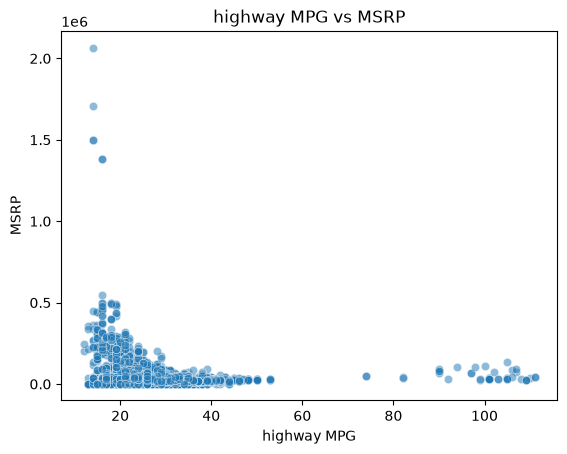

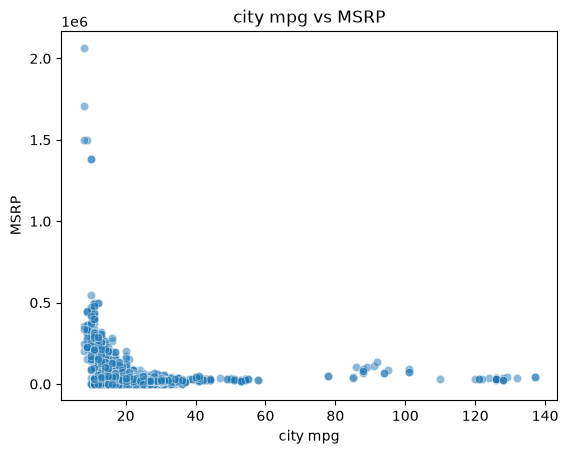

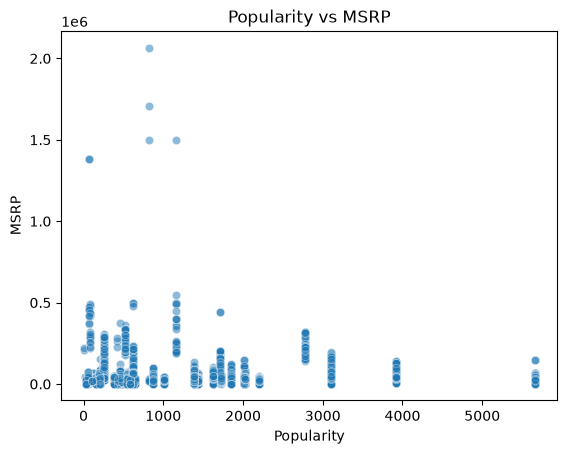

In [308]:
for column in selected_numeric:

    sns.scatterplot(data = train_df , x = column , y = 'MSRP', alpha = 0.5)

    plt.title(f'{column} vs MSRP')
    plt.show()

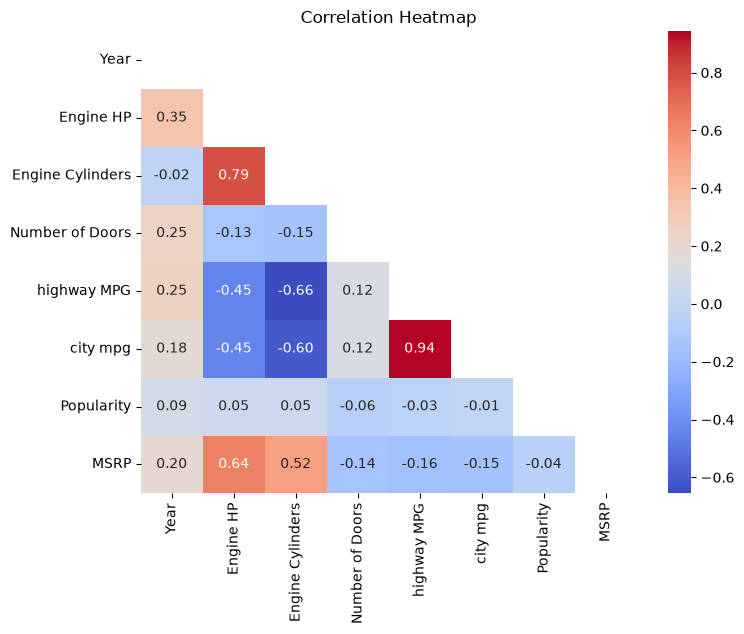

In [309]:
# TODO - No Code
train_df.corr(numeric_only=True)['MSRP'].abs().sort_values(ascending=False)

corr_matrix = train_df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [310]:
corr_matrix ['MSRP'].abs().sort_values(ascending=False)

MSRP                1.000000
Engine HP           0.636493
Engine Cylinders    0.515663
Year                0.196041
highway MPG         0.164291
city mpg            0.152016
Number of Doors     0.142159
Popularity          0.044736
Name: MSRP, dtype: float64

Questions:

- Which features seem most correlated with price?

### answer :

- Engine HP the highest corr with 0.636493

## Feature Engineering
Create at least two new features that may improve performance.

Possible ideas

- Engine HP per Cylinder

- Power-to-weight proxy


**You should do the same step for the `val` and `test`**

In [311]:
# TODO
reference_year = X_train['Year'].max()

def add_features(data):
    
    data = data.copy()

    data['HP_per_Cylinder'] = (data['Engine HP'] / data['Engine Cylinders'].replace(0, np.nan))

    data['Average_MPG'] = (data['city mpg'] + data['highway MPG']) / 2

    data['Car_Age'] = (reference_year - data['Year'])

    return data
    
X_train = add_features(X_train)
X_val = add_features(X_val)
X_test = add_features(X_test)  

X_train[['Engine HP','Engine Cylinders','HP_per_Cylinder','Average_MPG','Car_Age']].head()

,Engine HP,Engine Cylinders,HP_per_Cylinder,Average_MPG,Car_Age
6923,NaN,0.0,NaN,90.0,3
2787,200.0,4.0,50.000000,23.5,2
6158,190.0,6.0,31.666667,16.5,18
3048,185.0,4.0,46.250000,30.5,2
11266,185.0,6.0,30.833333,20.5,12


In [312]:
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

categorical_features = X_train.select_dtypes(include='str').columns.tolist()

In [313]:
numerical_features

['Year',
 'Engine HP',
 'Engine Cylinders',
 'Number of Doors',
 'highway MPG',
 'city mpg',
 'Popularity',
 'HP_per_Cylinder',
 'Average_MPG',
 'Car_Age']

In [314]:
categorical_features

['Make',
 'Model',
 'Engine Fuel Type',
 'Transmission Type',
 'Driven_Wheels',
 'Market Category',
 'Vehicle Size',
 'Vehicle Style']

## Preprocessing
Identify numerical and categorical columns and build a ColumnTransformer.

In [315]:
# TODO
numerical_pipeline = Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
categorical_pipeline = Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('numerical',numerical_pipeline,numerical_features),('categorical',categorical_pipeline,categorical_features)])

## Pipeline
Create a preprocessing + model pipeline.

In [316]:
# TODO
def evaluate_model(model, X_data, y_data):
    
    predictions = model.predict(X_data)

    mae = mean_absolute_error(y_data,predictions)

    mse = mean_squared_error(y_data,predictions)

    rmse = np.sqrt(mse)

    print(f"MAE = {mae:.3f}")
    print(f"MSE = {mse:.3f}")
    print(f"RMSE = {rmse:.3f}")

    return mae, mse, rmse

## Baseline Model
Train a Linear Regression model and evaluate using MAE, RMSE and MSE.

- Linear Regression

In [317]:
linear_pipeline = Pipeline([('preprocessing',preprocessor),('model',LinearRegression())])

linear_pipeline.fit(X_train,y_train)

linear_mae, linear_mse, linear_rmse = evaluate_model(linear_pipeline,X_val,y_val)

MAE = 4101.576
MSE = 91170982.591
RMSE = 9548.350


- Decision Tree

In [318]:
tree_pipeline = Pipeline([('preprocessing',preprocessor),('model',DecisionTreeRegressor(random_state=4) )])

tree_pipeline.fit(X_train,y_train)

tree_mae, tree_mse, tree_rmse = evaluate_model(tree_pipeline,X_val,y_val)

MAE = 3795.682
MSE = 80852284.785
RMSE = 8991.790


- Random Forest

In [319]:
forest_pipeline = Pipeline([('preprocessing',preprocessor),('model',RandomForestRegressor(n_estimators=100,random_state=4,n_jobs=-1))])

forest_pipeline.fit(X_train,y_train)

forest_mae, forest_mse, forest_rmse = evaluate_model(forest_pipeline,X_val,y_val)

MAE = 3442.260
MSE = 60204695.872
RMSE = 7759.169


How well does Linear Regression perform?

- Linear Regression performed okay as a baseline, but it had higher errors than Decision Tree and Random Forest.

## Model Comparison
Compare at least two regression models.

In [320]:
# TODO
results = pd.DataFrame({'Model': ['Linear Regression','Decision Tree','Random Forest'],

    'MAE': [linear_mae,tree_mae,forest_mae],

    'MSE': [linear_mse,tree_mse,forest_mse],

    'RMSE': [linear_rmse,tree_rmse,forest_rmse]})

results.sort_values('RMSE')

,Model,MAE,MSE,RMSE
2,Random Forest,3442.259777,6.020470e+07,7759.168504
1,Decision Tree,3795.681654,8.085228e+07,8991.789854
0,Linear Regression,4101.576319,9.117098e+07,9548.349731


## Hyperparameter Tuning
Tune your best model using GridSearchCV.

In [321]:
# TODO

grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [10, None]
}

grid_model = GridSearchCV(forest_pipeline,grid,cv=2,n_jobs=-1)

grid_model.fit(X_train, y_train)

print("Best GridSearch Parameters:")
print(grid_model.best_params_)

Best GridSearch Parameters:
{'model__max_depth': None, 'model__n_estimators': 100}


Repeat using RandomizedSearchCV.

In [322]:
# TODO

random_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [5, 10, 15, None]
}

random_model = RandomizedSearchCV(
    estimator=forest_pipeline,
    param_distributions=random_grid,
    n_iter=10,
    cv=3,
    random_state=4,
    n_jobs=-1
)

random_model.fit(X_train, y_train)

print("\nBest Parameters (RandomizedSearchCV):")
print(random_model.best_params_)


Best Parameters (RandomizedSearchCV):
{'model__n_estimators': 150, 'model__max_depth': 15}


In [323]:
grid_predictions = grid_model.predict(X_val)

mae = mean_absolute_error(y_val, grid_predictions)
mse = mean_squared_error(y_val, grid_predictions)
rmse = np.sqrt(mse)

print(f"MAE = {mae:.3f}")
print(f"MSE = {mse:.3f}")
print(f"RMSE = {rmse:.3f}")

random_predictions = random_model.predict(X_val)

mae = mean_absolute_error(y_val, random_predictions)
mse = mean_squared_error(y_val, random_predictions)
rmse = np.sqrt(mse)

print(f"MAE = {mae:.3f}")
print(f"MSE = {mse:.3f}")
print(f"RMSE = {rmse:.3f}")

grid_rmse = np.sqrt(
    mean_squared_error(y_val, grid_model.predict(X_val))
)

random_rmse = np.sqrt(
    mean_squared_error(y_val, random_model.predict(X_val))
)

print("GridSearch RMSE:", grid_rmse)
print("RandomizedSearch RMSE:", random_rmse)

MAE = 3442.260
MSE = 60204695.872
RMSE = 7759.169
MAE = 3655.451
MSE = 61420227.957
RMSE = 7837.106
GridSearch RMSE: 7759.168503904073
RandomizedSearch RMSE: 7837.105840640562


In [324]:
best_model = grid_model

Which method was faster? Did both produce similar results?

- RandomizedSearchCV was faster, while GridSearchCV achieved slightly better performance. Both methods produced similar results.

## Error Analysis (Bonus)

Predict on validation set

In [325]:
# TODO
y_pred = best_model.predict(X_val)

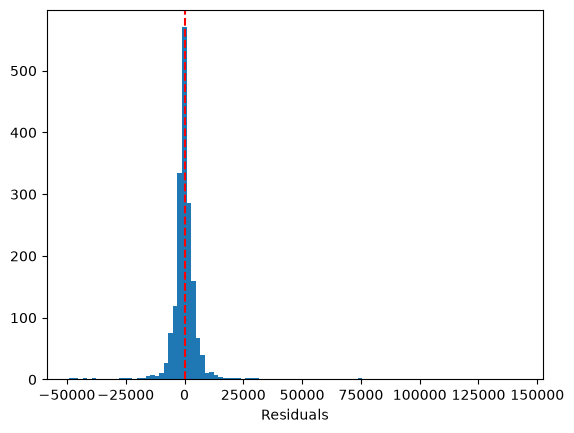

In [326]:
plt.hist(residuals, bins=100)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residuals")
plt.show()

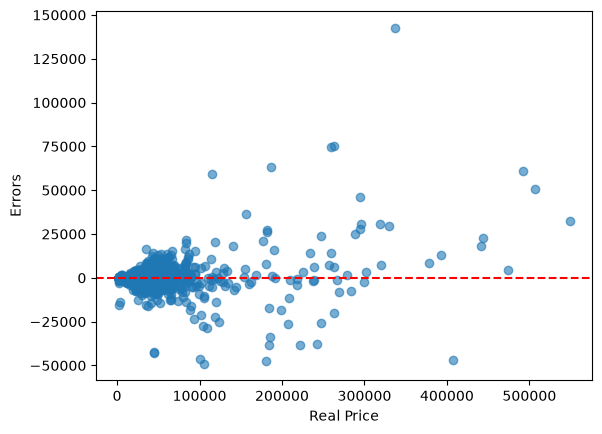

In [327]:
plt.scatter(y_val, residuals, alpha=0.6)
plt.xlabel("Real Price")
plt.ylabel("Errors")
plt.axhline(0, color="red", linestyle="--")
plt.show()

In [328]:
val_df = X_val.copy()

val_df["y_true"] = y_val
val_df["y_pred"] = y_pred
val_df["abs_error"] = np.abs(residuals)

val_df.sort_values(by="abs_error",ascending=False).head(20)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,...,Vehicle Style,highway MPG,city mpg,Popularity,HP_per_Cylinder,Average_MPG,Car_Age,y_true,y_pred,abs_error
2858,Bentley,Continental GT3-R,2015,premium unleaded (required),572.0,8.0,AUTOMATIC,all wheel drive,2.0,"Exotic,Factory Tuner,Luxury,High-Performance",...,Coupe,23,13,520,71.500000,18.0,2,337000,194277.690000,142722.310000
7444,Rolls-Royce,Park Ward,2002,premium unleaded (required),322.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury",...,Sedan,15,11,86,26.833333,13.0,15,262990,188012.120000,74977.880000
7443,Rolls-Royce,Park Ward,2001,premium unleaded (required),322.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury",...,Sedan,15,11,86,26.833333,13.0,16,259900,185536.070000,74363.930000
8313,Land Rover,Range Rover,2015,flex-fuel (premium unleaded required/E85),510.0,8.0,AUTOMATIC,four wheel drive,4.0,"Flex Fuel,Luxury,High-Performance",...,4dr SUV,19,13,258,63.750000,16.0,2,186495,123285.699603,63209.300397
7564,Rolls-Royce,Phantom,2016,premium unleaded (required),453.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,Performance",...,Sedan,19,11,86,37.750000,15.0,1,492425,431217.000000,61208.000000
5069,Mercedes-Benz,G-Class,2015,premium unleaded (required),382.0,8.0,AUTOMATIC,four wheel drive,4.0,Luxury,...,4dr SUV,15,12,617,47.750000,13.5,2,115400,56395.381667,59004.618333
698,Maybach,62,2010,premium unleaded (required),631.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,High-Performance",...,Sedan,16,10,67,52.583333,13.0,7,506500,456097.430000,50402.570000
8295,Land Rover,Range Rover,2014,premium unleaded (required),510.0,8.0,AUTOMATIC,four wheel drive,4.0,"Luxury,High-Performance",...,4dr SUV,19,13,258,63.750000,16.0,3,105300,154297.426310,48997.426310
2852,Bentley,Continental Flying Spur,2011,flex-fuel (premium unleaded required/E85),552.0,12.0,AUTOMATIC,all wheel drive,4.0,"Exotic,Flex Fuel,Luxury,High-Performance",...,Sedan,18,11,520,46.000000,14.5,6,181200,228822.136667,47622.136667
7561,Rolls-Royce,Phantom,2015,premium unleaded (required),453.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,Performance",...,Sedan,19,11,86,37.750000,15.0,2,407400,454374.416667,46974.416667


Compute residuals

`Actual - Predicted`

In [329]:
# TODO
residuals = y_val - y_pred
residuals

6293     3824.825000
9274     -426.980209
9586     5652.180617
5510    -2436.341667
5744     8839.295000
            ...     
9969     4717.396190
6865      843.378333
10905    2178.260000
10267   -2459.216905
10606   -2122.698333
Name: MSRP, Length: 1792, dtype: float64

Plot residuals, Predicted vs Actual, investigate largest errors.

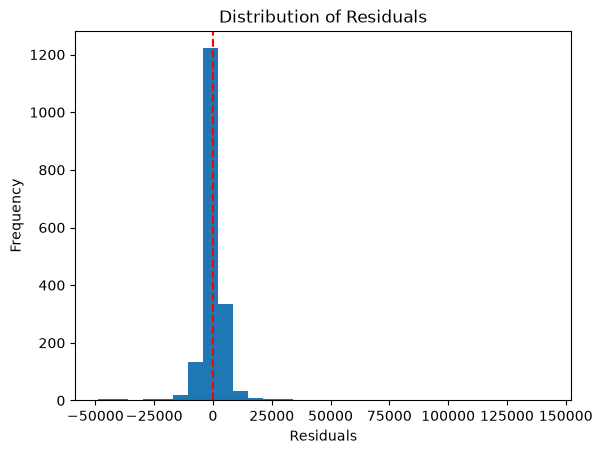

In [330]:
plt.hist(residuals, bins=30)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

- Where does the model fail?

In [331]:
#TODO-NO CODE

- The model struggles with luxury and exotic cars.

Which cars have the highest prediction errors?

In [332]:
#TODO-NO CODE

- Bentley and Rolls-Royce have the highest prediction errors, followed by Lamborghini and Land Rover.

Are expensive cars harder to predict?

In [333]:
#TODO-NO CODE

- Yes. Most of the largest errors are for high-priced luxury cars.

## Final Test Evaluation
Evaluate **only once** on the held-out test set.

In [334]:
# TODO
test_predictions = best_model.predict(X_test)

mae = mean_absolute_error(y_test, test_predictions)
mse = mean_squared_error(y_test, test_predictions)
rmse = np.sqrt(mse)

print("Test MAE:", mae)
print("Test MSE:", mse)
print("Test RMSE:", rmse)

Test MAE: 3446.8791448194143
Test MSE: 106792239.09325258
Test RMSE: 10334.033050714159


## Deployment (Bonus)
Deploy your model using streamlit

In [335]:
joblib.dump(best_model, "model.pkl")

['model.pkl']

## Reflection
Summarize findings.

- Which preprocessing steps were essential?
- Which model performed best?
- Why?
- Did hyperparameter tuning improve performance?
- Which features contributed most?
- What additional data would improve predictions?
- If this model were deployed in production, what challenges might arise?

### Which preprocessing steps were essential?

- Handling missing values, encoding categorical features, and scaling numerical features.

### Which model performed best?

- Random Forest performed best.

### Why?

- It achieved the lowest RMSE compared to the other models.

### Did hyperparameter tuning improve performance?

- Hyperparameter tuning did not significantly improve the model's performance.


### Which features contributed most?

- Feature importance was not analyzed in this project.

### What additional data would improve predictions?

- Vehicle mileage, accident history, and maintenance records could improve prediction accuracy.

### If this model were deployed in production, what challenges might arise?

- Missing data, new car models, and changing market prices may reduce prediction accuracy.

## Bonus Challenges - 1
- Remove outliers and compare. Did performance improve?
  


In [336]:
#TODO

## Bonus Challenges - 2

Perform feature selection